In [ ]:
# Install and configure PySpark
!apt-get install openjdk-11-jdk-headless -qq > /dev/null
!pip install pyspark -q

import pyspark
from pyspark.sql import SparkSession

# Create Spark session
spark = SparkSession.builder \
    .appName("Medication_Trend_Analysis") \
    .getOrCreate()

spark


In [ ]:
# PySpark
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count, when, to_date, year

# Visualization & Data Handling
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Define the file paths
base_path = "/content/" # This is the default Colab upload location

# Load the datasets
df_patients = spark.read.csv(f"{base_path}PATIENTS.csv", header=True, inferSchema=True)
df_admissions = spark.read.csv(f"{base_path}ADMISSIONS.csv", header=True, inferSchema=True)
df_prescriptions = spark.read.csv(f"{base_path}PRESCRIPTIONS.csv", header=True, inferSchema=True)

# Let's check the schemas to make sure they loaded correctly
print("Patients Schema:")
df_patients.printSchema()

print("Admissions Schema:")
df_admissions.printSchema()

print("Prescriptions Schema:")
df_prescriptions.printSchema()

Patients Schema:
root
 |-- row_id: integer (nullable = true)
 |-- subject_id: integer (nullable = true)
 |-- gender: string (nullable = true)
 |-- dob: timestamp (nullable = true)
 |-- dod: timestamp (nullable = true)
 |-- dod_hosp: timestamp (nullable = true)
 |-- dod_ssn: timestamp (nullable = true)
 |-- expire_flag: integer (nullable = true)

Admissions Schema:
root
 |-- row_id: integer (nullable = true)
 |-- subject_id: integer (nullable = true)
 |-- hadm_id: integer (nullable = true)
 |-- admittime: timestamp (nullable = true)
 |-- dischtime: timestamp (nullable = true)
 |-- deathtime: timestamp (nullable = true)
 |-- admission_type: string (nullable = true)
 |-- admission_location: string (nullable = true)
 |-- discharge_location: string (nullable = true)
 |-- insurance: string (nullable = true)
 |-- language: string (nullable = true)
 |-- religion: string (nullable = true)
 |-- marital_status: string (nullable = true)
 |-- ethnicity: string (nullable = true)
 |-- edregtime: time

In [ ]:
# Convert all column names to lowercase to avoid casing mismatches
def to_lowercase_cols(df):
    for c in df.columns:
        df = df.withColumnRenamed(c, c.lower())
    return df

df_patients = to_lowercase_cols(df_patients)
df_admissions = to_lowercase_cols(df_admissions)
df_prescriptions = to_lowercase_cols(df_prescriptions)

print("Normalized columns to lowercase. Example columns:")
print("patients:", df_patients.columns[:10])
print("admissions:", df_admissions.columns[:10])
print("prescriptions:", df_prescriptions.columns[:10])


Normalized columns to lowercase. Example columns:
patients: ['row_id', 'subject_id', 'gender', 'dob', 'dod', 'dod_hosp', 'dod_ssn', 'expire_flag']
admissions: ['row_id', 'subject_id', 'hadm_id', 'admittime', 'dischtime', 'deathtime', 'admission_type', 'admission_location', 'discharge_location', 'insurance']
prescriptions: ['row_id', 'subject_id', 'hadm_id', 'icustay_id', 'startdate', 'enddate', 'drug_type', 'drug', 'drug_name_poe', 'drug_name_generic']


In [ ]:
from pyspark.sql.functions import col

# Define expected columns (common names in demo); we will check and use only available ones
# Patients: subject_id, gender, dob (date of birth)
patients_cols = []
for c in ["subject_id","gender","dob","date_of_birth","dob_time"]:
    if c in df_patients.columns:
        patients_cols.append(c)
# Admissions: subject_id, hadm_id, admittime
admissions_cols = []
for c in ["subject_id","hadm_id","admittime","admit_time","admittime"]:
    if c in df_admissions.columns:
        admissions_cols.append(c)
# Prescriptions: subject_id, hadm_id, drug, startdate
presc_cols = []
for c in ["subject_id","hadm_id","drug","drug_name_poe","drug_name_generic","startdate","starttime","start"]:
    if c in df_prescriptions.columns:
        presc_cols.append(c)

print("Selected patient cols:", patients_cols)
print("Selected admission cols:", admissions_cols[:5])
print("Selected prescription cols:", presc_cols[:6])

# Narrow DataFrames to only necessary columns (if present)
df_pat = df_patients.select(*[col(c) for c in patients_cols]) if patients_cols else df_patients
df_adm = df_admissions.select(*[col(c) for c in admissions_cols]) if admissions_cols else df_admissions
df_presc = df_prescriptions.select(*[col(c) for c in presc_cols]) if presc_cols else df_prescriptions

print("Reduced dataframes prepared.")


Selected patient cols: ['subject_id', 'gender', 'dob']
Selected admission cols: ['subject_id', 'hadm_id', 'admittime', 'admittime']
Selected prescription cols: ['subject_id', 'hadm_id', 'drug', 'drug_name_poe', 'drug_name_generic', 'startdate']
Reduced dataframes prepared.


In [ ]:
from pyspark.sql.functions import to_timestamp, year, month, dayofmonth

# For patients: ensure DOB column named 'dob_ts'
dob_col = None
for c in ["dob","date_of_birth","dob_time"]:
    if c in df_pat.columns:
        dob_col = c
        break

if dob_col:
    df_pat = df_pat.withColumn("dob_ts", to_timestamp(col(dob_col)))
    print("Using patient dob column:", dob_col)
else:
    print("Warning: DOB column not found in patients; age-based analyses will be limited.")

# For admissions: ensure admittime column named admittime_ts
adm_time_col = None
for c in ["admittime","admit_time","admittime"]:
    if c in df_adm.columns:
        adm_time_col = c
        break
if adm_time_col:
    df_adm = df_adm.withColumn("admittime_ts", to_timestamp(col(adm_time_col)))
    print("Using admission time column:", adm_time_col)
else:
    print("Warning: ADMITTIME column not found in admissions; age-at-admission may be approximate.")

# For prescriptions: pick start timestamp
presc_time_col = None
for c in ["startdate","starttime","start","presc_start_ts","drug_start"]:
    if c in df_presc.columns:
        presc_time_col = c
        break
if presc_time_col:
    df_presc = df_presc.withColumn("presc_start_ts", to_timestamp(col(presc_time_col)))
    df_presc = df_presc.withColumn("presc_year", year(col("presc_start_ts")))
    print("Using prescriptions time column:", presc_time_col)
else:
    df_presc = df_presc.withColumn("presc_year", col(presc_cols[0]) * 0) if presc_cols else df_presc
    print("No prescription date found; yearly trends will be limited.")


Using patient dob column: dob
Using admission time column: admittime
Using prescriptions time column: startdate


In [ ]:
# Join order: prescriptions <- admissions <- patients (left joins where appropriate)
# We join on subject_id and hadm_id when possible to be precise; otherwise join on subject_id.

join_cols = []
if "hadm_id" in df_presc.columns and "hadm_id" in df_adm.columns:
    join_cols = ["subject_id","hadm_id"]
else:
    join_cols = ["subject_id"]
    print("Note: hadm_id not present in both PRESCRIPTIONS and ADMISSIONS — joining by subject_id only (coarser).")

# join prescriptions to admissions
df_join = df_presc.join(df_adm, on=join_cols, how="left")

# join patients to result
if "subject_id" in df_pat.columns:
    df_join = df_join.join(df_pat, on="subject_id", how="left")
else:
    print("subject_id missing in patients table; patient demographics will be unavailable.")

# show schema & sample rows
df_join.printSchema()
df_join.show(5, truncate=120)


root
 |-- subject_id: integer (nullable = true)
 |-- hadm_id: integer (nullable = true)
 |-- drug: string (nullable = true)
 |-- drug_name_poe: string (nullable = true)
 |-- drug_name_generic: string (nullable = true)
 |-- startdate: timestamp (nullable = true)
 |-- presc_start_ts: timestamp (nullable = true)
 |-- presc_year: integer (nullable = true)
 |-- admittime: timestamp (nullable = true)
 |-- admittime: timestamp (nullable = true)
 |-- admittime_ts: timestamp (nullable = true)
 |-- gender: string (nullable = true)
 |-- dob: timestamp (nullable = true)
 |-- dob_ts: timestamp (nullable = true)

+----------+-------+---------------------------+---------------------------+---------------------------+-------------------+-------------------+----------+-------------------+-------------------+-------------------+------+-------------------+-------------------+
|subject_id|hadm_id|                       drug|              drug_name_poe|          drug_name_generic|          startdate|     p

In [ ]:
from pyspark.sql.functions import col

# Drop rows with missing drug names
if "drug" in df_join.columns:
    df_join = df_join.filter(col("drug").isNotNull())
else:
    # try other drug name columns
    alt_drug_cols = [c for c in df_join.columns if "drug" in c and c != "drug"]
    if alt_drug_cols:
        # rename the first alt to 'drug' for convenience
        df_join = df_join.withColumnRenamed(alt_drug_cols[0], "drug")
        print(f"Renamed {alt_drug_cols[0]} to 'drug'")
    else:
        raise ValueError("No drug column found in prescriptions. Check PRESCRIPTIONS.csv for drug name columns.")

# Ensure subject_id exists
if "subject_id" not in df_join.columns:
    raise ValueError("subject_id missing after joins — cannot continue.")

print("After cleaning, total rows:", df_join.count())


After cleaning, total rows: 10398


In [ ]:
from pyspark.sql.functions import count, desc

top_drugs = df_join.groupBy("drug").agg(count("*").alias("total_prescriptions")) \
                    .orderBy(desc("total_prescriptions"))

print("Top 10 most prescribed drugs:")
top_drugs.limit(10).show(truncate=80)


Top 10 most prescribed drugs:
+---------------------------+-------------------+
|                       drug|total_prescriptions|
+---------------------------+-------------------+
|         Potassium Chloride|                529|
|                        D5W|                439|
|       0.9% Sodium Chloride|                409|
|                         NS|                362|
|                 Furosemide|                346|
|                    Insulin|                300|
|       Iso-Osmotic Dextrose|                265|
|                5% Dextrose|                256|
|                         SW|                244|
|Sodium Chloride 0.9%  Flush|                206|
+---------------------------+-------------------+



In [ ]:
# Count prescriptions per subject
presc_per_patient = df_join.groupBy("subject_id").agg(count("drug").alias("num_prescriptions"))

# Average number (global)
avg_num = presc_per_patient.selectExpr("avg(num_prescriptions) as avg_presc").collect()[0]["avg_presc"]
print(f"Average number of prescriptions per patient: {avg_num:.2f}")

# Show distribution summary
presc_per_patient.describe("num_prescriptions").show()


Average number of prescriptions per patient: 110.62
+-------+------------------+
|summary| num_prescriptions|
+-------+------------------+
|  count|                94|
|   mean|110.61702127659575|
| stddev|156.58349014050037|
|    min|                15|
|    max|              1158|
+-------+------------------+



In [ ]:
# We need gender column in df_join (from patients). Common name 'gender'
if "gender" not in df_join.columns:
    print("Gender column not present in merged data; cannot compute drug by gender.")
else:
    drug_by_gender = df_join.groupBy("gender").agg(count("drug").alias("total_drugs")).orderBy("gender")
    drug_by_gender.show()


+------+-----------+
|gender|total_drugs|
+------+-----------+
|     F|       4916|
|     M|       5482|
+------+-----------+



In [ ]:
from pyspark.sql.functions import when

# Need dob_ts and admittime_ts to compute age at admission
if ("dob_ts" in df_join.columns) and ("admittime_ts" in df_join.columns):
    df_join = df_join.withColumn("age", year(col("admittime_ts")) - year(col("dob_ts")))
    df_join = df_join.withColumn("age_group",
        when(col("age") < 21, "0-20")
        .when((col("age") >= 21) & (col("age") <= 40), "21-40")
        .when((col("age") >= 41) & (col("age") <= 60), "41-60")
        .otherwise("60+")
    )
    # Count drugs per age_group
    drug_by_age = df_join.groupBy("age_group").agg(count("drug").alias("total_drugs")).orderBy("age_group")
    drug_by_age.show()
else:
    print("DOB or ADMITTIME not available in joined data — cannot compute age groups.")


+---------+-----------+
|age_group|total_drugs|
+---------+-----------+
|     0-20|        189|
|    21-40|        124|
|    41-60|       2741|
|      60+|       7344|
+---------+-----------+



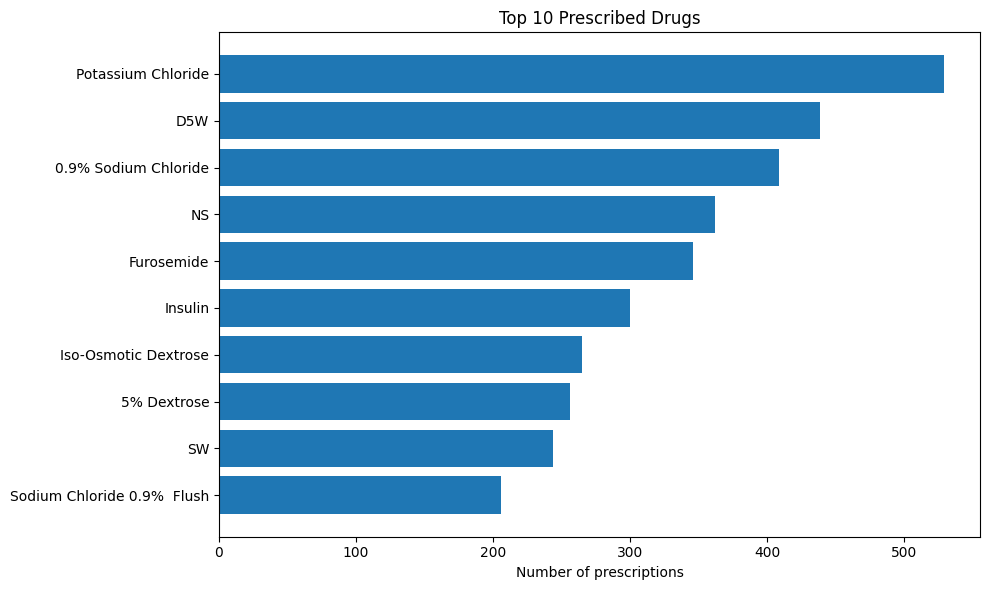

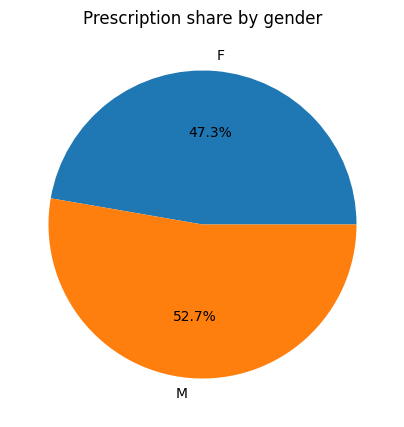

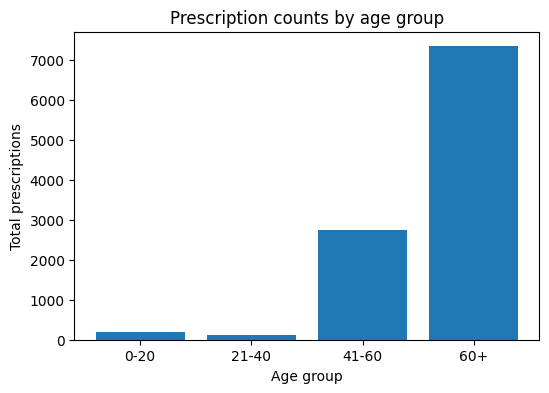

In [ ]:
import matplotlib.pyplot as plt

# Top drugs bar plot
top10_pd = top_drugs.limit(10).toPandas().sort_values("total_prescriptions", ascending=True)  # for horizontal bar
plt.figure(figsize=(10,6))
plt.barh(top10_pd["drug"], top10_pd["total_prescriptions"])
plt.title("Top 10 Prescribed Drugs")
plt.xlabel("Number of prescriptions")
plt.tight_layout()
plt.show()

# Gender pie (if available)
if "gender" in df_join.columns:
    gender_pd = drug_by_gender.toPandas()
    plt.figure(figsize=(5,5))
    plt.pie(gender_pd["total_drugs"], labels=gender_pd["gender"], autopct="%1.1f%%")
    plt.title("Prescription share by gender")
    plt.show()

# Age group bar (if available)
if "age_group" in df_join.columns:
    age_pd = drug_by_age.toPandas()
    plt.figure(figsize=(6,4))
    plt.bar(age_pd["age_group"], age_pd["total_drugs"])
    plt.title("Prescription counts by age group")
    plt.xlabel("Age group")
    plt.ylabel("Total prescriptions")
    plt.show()


In [ ]:
# load diagnoses if not already loaded, and normalize lowercase
if 'df_diagnoses' not in globals():
    # try to load from /content if file exists
    import os
    diag_path = f"{base_path}DIAGNOSES_ICD.csv"
    if os.path.exists(diag_path):
        df_diagnoses = spark.read.csv(diag_path, header=True, inferSchema=True)
        df_diagnoses = to_lowercase_cols(df_diagnoses)
        print("Loaded DIAGNOSES_ICD.csv")
    else:
        df_diagnoses = None
        print("DIAGNOSES_ICD.csv not found in /content; top drugs per disease will be skipped.")

if df_diagnoses is not None:
    # select useful columns and join (subject_id, hadm_id, icd9_code)
    cols_diag = []
    for c in ["subject_id","hadm_id","icd9_code","icd9"]:
        if c in df_diagnoses.columns:
            cols_diag.append(c)
    df_diag_sel = df_diagnoses.select(*cols_diag)

    # join with prescriptions on subject_id + hadm_id if available
    join_cols_diag = ["subject_id","hadm_id"] if ("hadm_id" in df_diag_sel.columns and "hadm_id" in df_presc.columns) else ["subject_id"]
    presc_diag = df_presc.join(df_diag_sel, on=join_cols_diag, how="inner")

    # count drug per icd9
    from pyspark.sql.functions import desc
    drug_per_disease = presc_diag.groupBy("icd9_code","drug").agg(count("*").alias("count")).orderBy("icd9_code", desc("count"))
    print("Sample top drug per disease (first 20 rows):")
    drug_per_disease.limit(20).show(truncate=100)
else:
    print("Skipping disease-level analysis.")


DIAGNOSES_ICD.csv not found in /content; top drugs per disease will be skipped.
Skipping disease-level analysis.


In [ ]:
# Save top drugs, gender and age tables as CSV in /content for download
top_drugs.limit(100).toPandas().to_csv("/content/top_drugs_overall.csv", index=False)
print("Saved /content/top_drugs_overall.csv")

if "gender" in df_join.columns:
    drug_by_gender.toPandas().to_csv("/content/drugs_by_gender.csv", index=False)
    print("Saved /content/drugs_by_gender.csv")
if "age_group" in df_join.columns:
    drug_by_age.toPandas().to_csv("/content/drugs_by_age_group.csv", index=False)
    print("Saved /content/drugs_by_age_group.csv")
if 'drug_per_disease' in globals():
    drug_per_disease.limit(1000).toPandas().to_csv("/content/top_drugs_per_icd9.csv", index=False)
    print("Saved /content/top_drugs_per_icd9.csv")

print("All done — CSVs ready to download from Colab Files pane.")


Saved /content/top_drugs_overall.csv
Saved /content/drugs_by_gender.csv
Saved /content/drugs_by_age_group.csv
All done — CSVs ready to download from Colab Files pane.
